# IMPORT MODULES, INSTANTIATE CLASS

In [1]:
from geoai.utils_geo.RasterOps import RasterOperations
raster_ops = RasterOperations()

In [2]:
RASTER_FILE_PATH = "s2_data/QC_S2.tif"

# READ RASTER METADATA

In [3]:
raster_metadata = raster_ops.read_raster_metadata(RASTER_FILE_PATH)

# READ RASTER AS ARRAY

In [4]:
raster_as_array = raster_ops.raster_to_array(RASTER_FILE_PATH)

# COMPUTE FOR NDVI 

In [5]:
# get the RED and NIR band
red = raster_as_array[0]
nir = raster_as_array[1]

# compute ndvi
ndvi = raster_ops.compute_ndvi(nir, red)

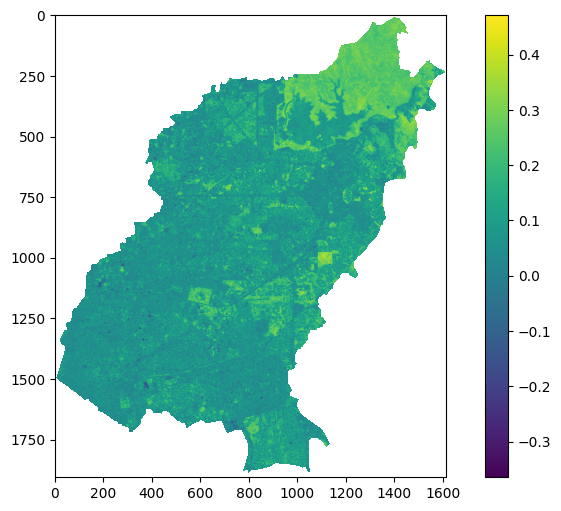

In [6]:
# VISUALIZE
raster_ops.visualize_array(ndvi)

# MASK NON VEGETATION AREAS BASED ON NDVI VALUES

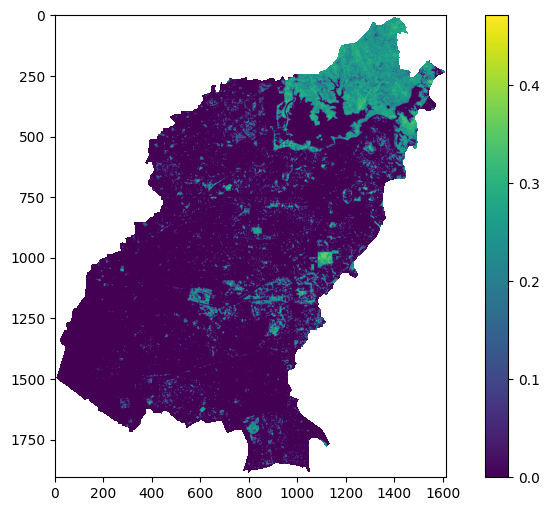

In [7]:
# DEFINE THRESHOLD
ndvi_threshold = 0.2

# CREATE A MASK RASTER
non_vegetation_mask = ndvi < ndvi_threshold

# APPLY THE MASK
vegetation_ndvi = raster_ops.apply_mask(ndvi, non_vegetation_mask, mask_value=0)

# VISUALIZE THE MASKED DATA
raster_ops.visualize_array(vegetation_ndvi)

# EXPORT

In [8]:
ndvi_masked_path = "raster_files/ndvi_masked.tif"
raster_ops.export_raster(vegetation_ndvi, raster_metadata, ndvi_masked_path)

In [9]:
# EXPORT MULTI-BAND RASTER
rgbnirndvi_path = "raster_files/rgbnirndvi.tif"
rgbnirndvi = raster_ops.add_band(raster_as_array, raster_metadata, ndvi)
raster_ops.export_raster(rgbnirndvi, raster_metadata, rgbnirndvi_path)

END